# Para quem a política funciona? Double ML no experimento NSW/Lalonde

**V1 · notebook reprodutível de ponta a ponta.** Projeto 3 do `data-science-lab`.

O experimento NSW dá o gabarito (ATE = +US$ 1.794). Trocamos os controles experimentais
pelos 2.490 controles do PSID e perguntamos: OLS, DML partialling-out e AIPW/IRM
conseguem recuperar o benchmark a partir de dados observacionais? E, no experimento,
**para quem** o treinamento funciona (CATE)?

In [1]:
from src import config as C
from src import analysis

exp, obs = analysis.fetch()
print(f"experimental n={len(exp)}  |  observacional (NSW tratados + PSID) n={len(obs)}")
exp.head(3)

experimental n=445  |  observacional (NSW tratados + PSID) n=2675


,treat,age,educ,black,hisp,married,nodegree,re74,re75,re78
0,1.0,37.0,11.0,1.0,0.0,1.0,1.0,0.0,0.0,9930.046
1,1.0,22.0,9.0,0.0,1.0,0.0,1.0,0.0,0.0,3595.894
2,1.0,30.0,12.0,1.0,0.0,0.0,0.0,0.0,0.0,24909.450


## O corredor polonês: cada estimador contra o benchmark

Nuisances em LightGBM com cross-fitting 5-fold. O AIPW/IRM é implementado na unha
(score de Neyman em ~15 linhas) — sem caixa-preta.

In [2]:
bench = analysis.experimental_benchmark(exp)
e, m1, m0 = analysis.crossfit_nuisances(obs)
rows = [bench,
        analysis.naive_diff(obs),
        analysis.ols_covs(obs),
        analysis.dml_plr(obs),
        analysis.aipw(obs, e, m1, m0, label="AIPW/IRM cross-fitted"),
        analysis.aipw(obs, e, m1, m0, lo=0.10, hi=0.90, label="AIPW/IRM overlap")]
import pandas as pd
display(pd.DataFrame(rows).round(0))

C:\Users\be\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,metodo,ate,se,n
0,Experimento NSW (benchmark),1794.0,671.0,445
1,Diferença de médias (ingênua),-15205.0,656.0,2675
2,OLS com controles,752.0,783.0,2675
3,DML partialling-out (LightGBM),-1679.0,855.0,2675
4,AIPW/IRM cross-fitted,-11380.0,4020.0,2675
5,AIPW/IRM overlap,-2592.0,1591.0,387


  fig -> D:\labs\data-science-lab\double-ml-heterogeneidade\outputs\figures\ate_gauntlet.png


  fig -> D:\labs\data-science-lab\double-ml-heterogeneidade\outputs\figures\overlap.png


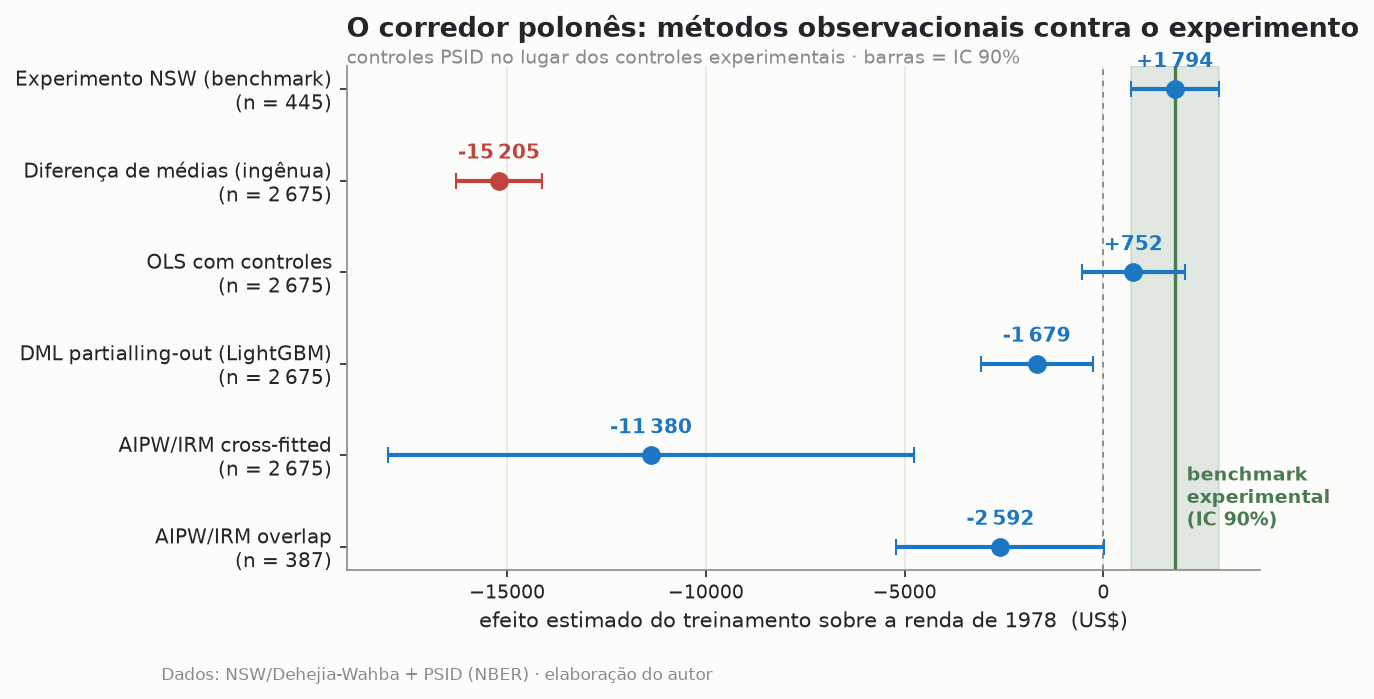

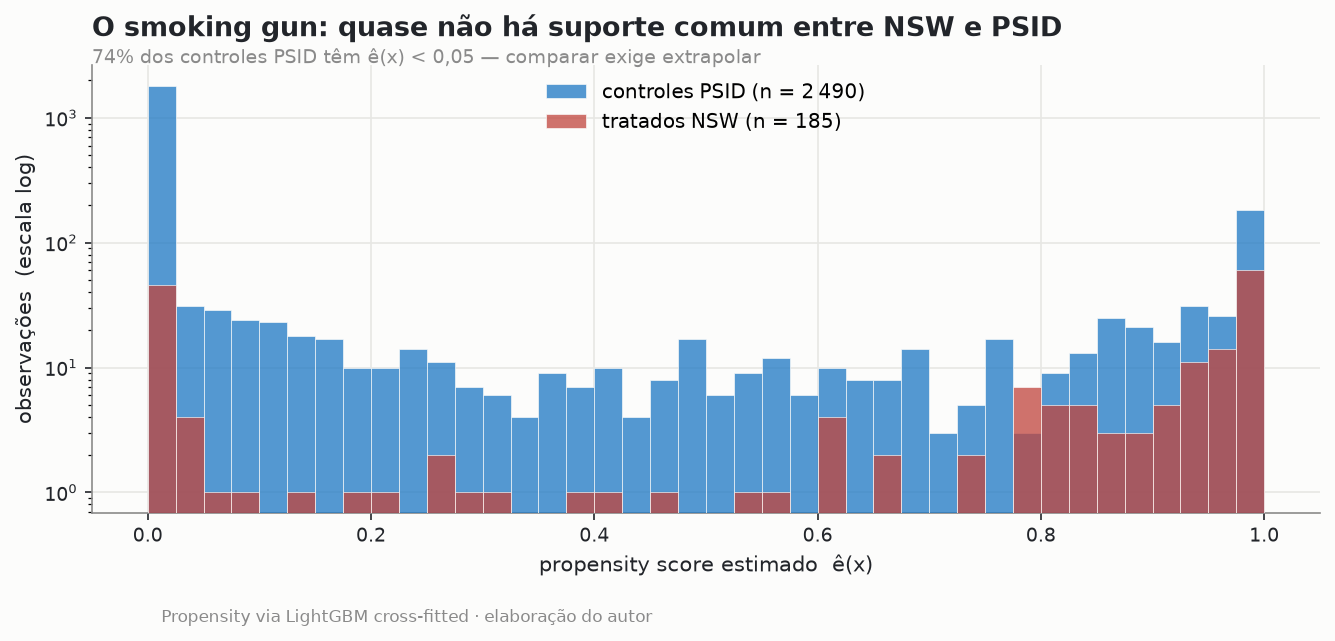

In [3]:
analysis.fig_gauntlet(rows, bench)
analysis.fig_overlap(obs, e)
from IPython.display import Image, display
display(Image(str(C.FIGURES / "ate_gauntlet.png")))
display(Image(str(C.FIGURES / "overlap.png")))

## CATE — para quem funciona? (na amostra experimental)

Heterogeneidade estimada onde a identificação é limpa (aleatorização), com DML linear
em (idade, escolaridade).

  fig -> D:\labs\data-science-lab\double-ml-heterogeneidade\outputs\figures\cate_by_age.png


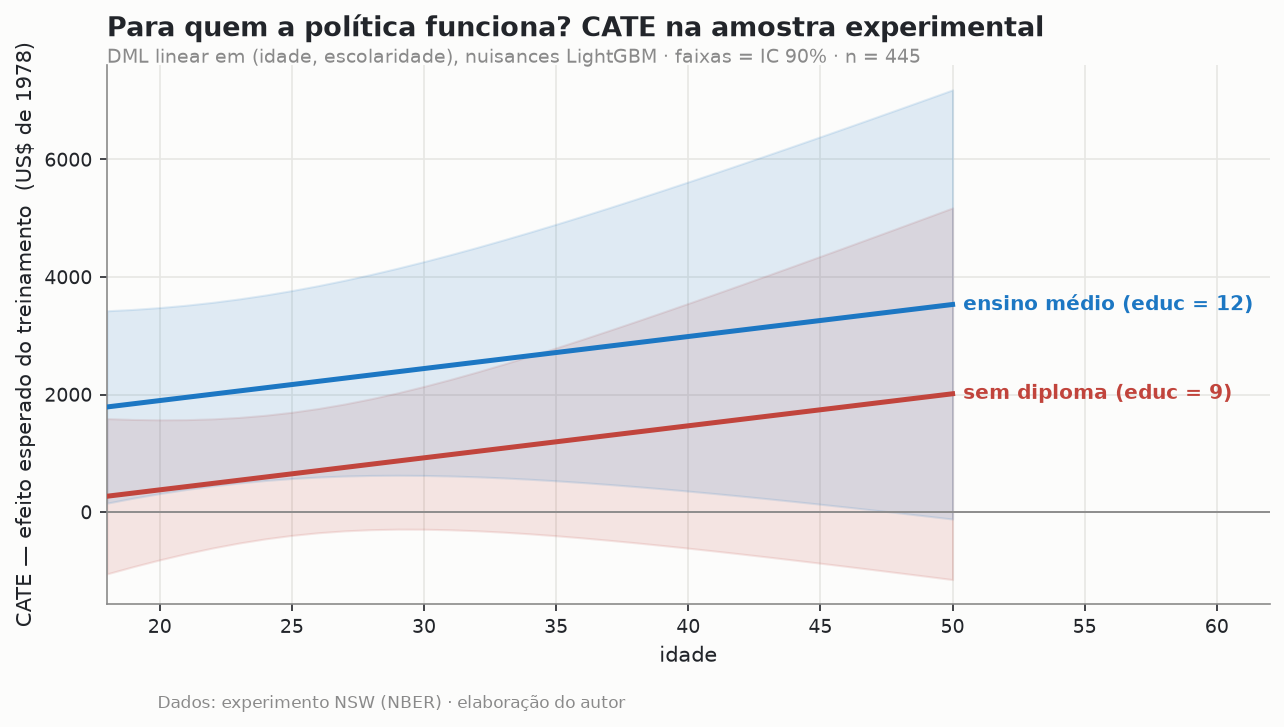

In [4]:
est = analysis.cate_experimental(exp)
analysis.fig_cate(est)
display(Image(str(C.FIGURES / "cate_by_age.png")))

## Conclusão honesta

1. A comparação ingênua com o PSID erra por **US$ 17 mil** e inverte o sinal.
2. O DML remove **~80% do viés** automaticamente — muito, e não suficiente.
3. O resíduo é **falha de identificação**, não de algoritmo: 74% dos controles PSID têm
   propensity < 0,05 (sem suporte comum) e a seleção remanescente é em não-observáveis
   (Ashenfelter dip). Nem AIPW duplamente robusto com trimming escapa.
4. **A lição de LaLonde (1986) sobrevive ao ML de 2018** (cf. Imbens & Xu, 2024): DML é
   ferramenta para quando a identificação está de pé — não substituto para desenho.
5. CATE no experimento: efeito **cresce com idade e escolaridade** — o treinamento rende
   mais para quem tem capital humano para convertê-lo. ICs largos (n = 445): sugerido,
   não provado.

**V2**: Causal Forests (Athey–Wager), calibração de CATE, política de targeting
out-of-sample e um experimento em escala (Criteo Uplift).